# RQ1: Hybrid Anonymization + DP-SGD for Emotion Detection

**Research Question**: To what extent does a hybrid privacy strategy that combines selective anonymization with DP-SGD reduce privacy risk while preserving emotion-detection performance in mental-health chatbot models relative to non-private, anonymization-only, and DP-only baselines?

## Methodology:
1. Train 4 RoBERTa-base variants:
   - **V0_BASELINE**: Raw text (no privacy)
   - **V1_ANONYM**: Anonymized text only
   - **V2_DP_SGD**: DP-SGD on raw text (ε=8, δ=1e-5)
   - **V3_HYBRID**: DP-SGD on anonymized text (ε=8, δ=1e-5)

2. Evaluate privacy (exact memorization) + utility (F1-macro)
3. Compare hybrid vs standalone effectiveness

In [1]:
!pip install opacus

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 254.4/254.4 kB 5.9 MB/s eta 0:00:00


In [2]:
# Import necessary libraries
import os
import sys
import pathlib
import pandas as pd
import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader
from torch.optim import Adam
from transformers import AutoTokenizer, AutoModelForSequenceClassification, get_linear_schedule_with_warmup
import matplotlib.pyplot as plt
from sklearn.metrics import f1_score, precision_score, recall_score
from tqdm import tqdm
import warnings
from opacus import PrivacyEngine
from opacus.utils.batch_memory_manager import BatchMemoryManager

warnings.filterwarnings('ignore')

# Device configuration
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")

Device: cuda


In [ ]:
import os
import pathlib
import sys

# 1. Mount Google Drive
try:
    from google.colab import drive
    drive.mount('/content/drive')
    IN_COLAB = True
except Exception:
    IN_COLAB = False
    print("Not running in Colab environment")

# 2. Find Project Root and Data Paths
if IN_COLAB:
    # Find the repository folder in Drive
    POSSIBLE_ROOTS = [
        '/content/drive/MyDrive',
        '/content/drive/My Drive'
    ]
    PROJECT_ROOT = None
    for pr in POSSIBLE_ROOTS:
        if os.path.exists(pr):
            PROJECT_ROOT = pathlib.Path(pr)
            break

    if PROJECT_ROOT is None:
        print("WARNING: Project root not found in Google Drive. Creating default paths.")
        PROJECT_ROOT = pathlib.Path('/content/drive/MyDrive')
else:
    # Local environment
    PROJECT_ROOT = pathlib.Path(os.getcwd())
    if 'src' in PROJECT_ROOT.parts:
        PROJECT_ROOT = PROJECT_ROOT.parents[PROJECT_ROOT.parts.index('src') - 1]

print(f"Project Root: {PROJECT_ROOT}")
sys.path.append(str(PROJECT_ROOT))

RAW_PATH = PROJECT_ROOT / 'content' / 'data' / 'raw' / 'go_emotions_dataset.csv'
CLEANED_PATH = PROJECT_ROOT / 'content' / 'data' / 'processed' / 'go_emotions_cleaned.csv'
OUTPUT_DIR = PROJECT_ROOT / 'models' / 'rq1_variants'
REPORT_DIR = PROJECT_ROOT / 'reports' / 'rq1'

os.makedirs(OUTPUT_DIR, exist_ok=True)
os.makedirs(REPORT_DIR, exist_ok=True)

# Load datasets
df_raw = pd.read_csv(RAW_PATH)
df_cleaned = pd.read_csv(CLEANED_PATH)

print(f"Raw: {df_raw.shape} | Cleaned: {df_cleaned.shape}")

# Identify emotion columns
emotion_columns = ['admiration', 'amusement', 'anger', 'annoyance', 'approval', 'caring',
                   'confusion', 'curiosity', 'desire', 'disappointment', 'disapproval',
                   'disgust', 'embarrassment', 'excitement', 'fear', 'gratitude', 'grief',
                   'joy', 'love', 'nervousness', 'optimism', 'pride', 'realization',
                   'relief', 'remorse', 'sadness', 'surprise', 'neutral']
df_cleaned['labels'] = df_cleaned[emotion_columns].values.tolist()

# Identify unique plabels count
num_emotions = len(emotion_columns)

# Tokenize the dataset
tokenizer = AutoTokenizer.from_pretrained("roberta-base")
df_cleaned['input_ids'] = df_cleaned['text'].apply(
    lambda x: tokenizer.encode(x, add_special_tokens=True, truncation=True, max_length=128)
    )

from transformers import DataCollatorWithPadding
# Pad input_ids to the same length
data_collator = DataCollatorWithPadding(tokenizer=tokenizer, return_tensors="pt")
padded_inputs = data_collator([{"input_ids": input_id} for input_id in df_cleaned['input_ids']])
df_cleaned['input_ids'] = list(padded_inputs['input_ids'])

# Convert input_ids and labels to proper tensor format
df_cleaned['input_ids'] = df_cleaned['input_ids'].apply(lambda x: torch.tensor(x, dtype=torch.long))
df_cleaned['labels'] = df_cleaned['labels'].apply(lambda x: torch.tensor(x, dtype=torch.float))

# Define the model (correct num_labels)
model = AutoModelForSequenceClassification.from_pretrained("roberta-base", num_labels=num_emotions)
model.to(device)

Mounted at /content/drive
Project Root: /content/drive/MyDrive
Raw: (211225, 31) | Cleaned: (57414, 32)


config.json:   0%|          | 0.00/481 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/499M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.dense.weight            | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
classifier.dense.weight         | MISSING    | 
classifier.out_proj.bias        | MISSING    | 
classifier.out_proj.weight      | MISSING    | 
classifier.dense.bias           | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


RobertaForSequenceClassification(
  (roberta): RobertaModel(
    (embeddings): RobertaEmbeddings(
      (word_embeddings): Embedding(50265, 768, padding_idx=1)
      (token_type_embeddings): Embedding(1, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
      (position_embeddings): Embedding(514, 768, padding_idx=1)
    )
    (encoder): RobertaEncoder(
      (layer): ModuleList(
        (0-11): 12 x RobertaLayer(
          (attention): RobertaAttention(
            (self): RobertaSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): RobertaSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
             

Prepare Train/Val/Test Splits

In [4]:
from sklearn.model_selection import train_test_split

meta_cols = {'id', 'text', 'example_very_unclear', 'clean_text', 'num_emotions', 'emotion_bin'}
emotion_cols = [col for col in df_raw.columns if col not in meta_cols]
print(f"emotion_cols: {len(emotion_cols)} → {emotion_cols}")

print(f"Emotion columns: {len(emotion_cols)}")

emotion_cols: 28 → ['admiration', 'amusement', 'anger', 'annoyance', 'approval', 'caring', 'confusion', 'curiosity', 'desire', 'disappointment', 'disapproval', 'disgust', 'embarrassment', 'excitement', 'fear', 'gratitude', 'grief', 'joy', 'love', 'nervousness', 'optimism', 'pride', 'realization', 'relief', 'remorse', 'sadness', 'surprise', 'neutral']
Emotion columns: 28


In [5]:
# Merge datasets on ID
df = df_raw.copy()
df = df.merge(df_cleaned[['id', 'clean_text']], on='id', how='inner')

# Stratify by high-emotion texts
df['num_emotions'] = df[emotion_cols].sum(axis=1)

# Use qcut with duplicates='drop' to handle skewed distributions
df['emotion_bin'] = pd.qcut(df['num_emotions'], q=3, duplicates='drop')

# Dynamically rename categories to match expected labels
n_bins = len(df['emotion_bin'].cat.categories)
label_map = {i: label for i, label in enumerate(['low', 'med', 'high'][:n_bins])}
df['emotion_bin'] = df['emotion_bin'].cat.rename_categories(label_map)

print(f"Stratification created {n_bins} bins: {df['emotion_bin'].value_counts().sort_index().to_dict()}")

# 60% train, 20% val, 20% test
train_idx, temp_idx = train_test_split(
    range(len(df)), test_size=0.4, random_state=42, stratify=df['emotion_bin']
)
val_idx, test_idx = train_test_split(
    temp_idx, test_size=0.5, random_state=42, stratify=df.loc[temp_idx, 'emotion_bin']
)

df_train = df.iloc[train_idx].reset_index(drop=True)
df_val = df.iloc[val_idx].reset_index(drop=True)
df_test = df.iloc[test_idx].reset_index(drop=True)

print(f"Train: {len(df_train)} | Val: {len(df_val)} | Test: {len(df_test)}")

Stratification created 2 bins: {Interval(-0.001, 1.0, closed='right'): 173342, Interval(1.0, 12.0, closed='right'): 35848}
Train: 125514 | Val: 41838 | Test: 41838


Create Text Variants

In [6]:
def prepare_variant_texts(df_split, text_col='text'):
    return df_split[text_col].astype(str).str.lower().tolist()

# Prepare V0_BASELINE variant using the original 'text' column
train_v0 = prepare_variant_texts(df_train, 'text')
val_v0 = prepare_variant_texts(df_val, 'text')
test_v0 = prepare_variant_texts(df_test, 'text')

# Prepare V1_ANONYM variant using the anonymized 'clean_text' column
train_v1 = prepare_variant_texts(df_train, 'clean_text')
val_v1 = prepare_variant_texts(df_val, 'clean_text')
test_v1 = prepare_variant_texts(df_test, 'clean_text')

print(f"Sample V0: {train_v0[0][:100]}...")
print(f"Sample V1: {train_v1[0][:100]}...")

Sample V0: sunni scum - check saudi vermin - check what more can you expect, this is the lowest form life can t...
Sample V1: sunni scum - check saudi vermin - check what more can you expect, this is the lowest form life can t...


Multi-Label Emotion Dataset

In [7]:
# Custom Dataset for emotion classification
class EmotionDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len=128):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):

        encoding = self.tokenizer(
            self.texts[idx],
            padding="max_length",
            truncation=True,
            max_length=self.max_len,
            return_tensors="pt"
        )

        return {
            "input_ids": encoding["input_ids"].squeeze(0),
            "attention_mask": encoding["attention_mask"].squeeze(0),
            "labels": torch.tensor(self.labels[idx]).float()
        }


# Prepare labels for each split
# Multi-label arrays (num_samples x num_emotions) converted to float32
train_labels = df_train[emotion_cols].values.astype(np.float32)
val_labels = df_val[emotion_cols].values.astype(np.float32)
test_labels = df_test[emotion_cols].values.astype(np.float32)

print(f"Label shapes: {train_labels.shape}")

Label shapes: (125514, 28)


Model Training Loop

In [16]:
class RobertaHeadOnlyClassifier(torch.nn.Module):
    """
    Freeze ALL RoBERTa weights. Train a 2-layer MLP head on mean-pooled embeddings.
    Key improvements over single Linear:
      1. Mean pooling (not CLS) — gives richer frozen representations
      2. Bottleneck MLP (768→256→28) — learns non-linear emotion boundaries
      3. Dropout — regularises against DP noise
    Total trainable: ~200K params (better signal/noise ratio under DP).
    """
    def __init__(self, roberta_model, num_labels, hidden_dim=256, dropout=0.1):
        super().__init__()
        self.roberta = roberta_model.roberta
        hidden_size  = roberta_model.config.hidden_size

        for param in self.roberta.parameters():
            param.requires_grad = False

        self.classifier = torch.nn.Sequential(
            torch.nn.Linear(hidden_size, hidden_dim),
            torch.nn.GELU(),
            torch.nn.Dropout(dropout),
            torch.nn.Linear(hidden_dim, num_labels),
        )

        # Xavier init for all linear layers
        for m in self.classifier:
            if isinstance(m, torch.nn.Linear):
                torch.nn.init.xavier_uniform_(m.weight)
                torch.nn.init.zeros_(m.bias)

    def forward(self, input_ids, attention_mask):
        with torch.no_grad():
            outputs = self.roberta(input_ids=input_ids, attention_mask=attention_mask)
        # Mean pooling: average over non-padding tokens
        hidden = outputs.last_hidden_state                       # (B, seq, 768)
        mask   = attention_mask.unsqueeze(-1).float()             # (B, seq, 1)
        pooled = (hidden * mask).sum(dim=1) / mask.sum(dim=1)    # (B, 768)
        return self.classifier(pooled)


class RobertaLinearClassifier(torch.nn.Module):
    """
    Freeze layers 0-9, train layers 10-11 + linear head.
    Used for NON-DP variants (V0, V1) where noise is not a concern.
    """
    def __init__(self, roberta_model, num_labels, freeze_layers=10):
        super().__init__()
        self.roberta  = roberta_model.roberta
        hidden_size   = roberta_model.config.hidden_size

        for param in self.roberta.embeddings.parameters():
            param.requires_grad = False
        for layer in self.roberta.encoder.layer[:freeze_layers]:
            for param in layer.parameters():
                param.requires_grad = False
        for layer in self.roberta.encoder.layer[freeze_layers:]:
            for param in layer.parameters():
                param.requires_grad = True

        self.classifier = torch.nn.Linear(hidden_size, num_labels)
        torch.nn.init.xavier_uniform_(self.classifier.weight)
        torch.nn.init.zeros_(self.classifier.bias)

    def forward(self, input_ids, attention_mask):
        outputs    = self.roberta(input_ids=input_ids, attention_mask=attention_mask)
        cls_output = outputs.last_hidden_state[:, 0, :]
        return self.classifier(cls_output)

In [17]:
def find_best_threshold(model, val_loader, val_labels_val, device, is_dp=False):
    """
    Sweep thresholds on validation set and return the one maximising F1-macro.
    Prints prediction distribution diagnostics to catch collapse early.
    """
    model.eval()
    val_preds_raw = []

    with torch.no_grad():
        for batch in val_loader:
            input_ids      = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            outputs        = model(input_ids=input_ids, attention_mask=attention_mask)
            logits         = outputs if isinstance(outputs, torch.Tensor) else outputs.logits
            probs          = torch.sigmoid(logits).cpu().numpy()
            val_preds_raw.append(probs)

    val_preds_raw = np.vstack(val_preds_raw)

    # Diagnostic: catch sigmoid collapse before sweep
    mean_prob      = val_preds_raw.mean()
    frac_above_05  = (val_preds_raw > 0.05).mean()
    frac_above_30  = (val_preds_raw > 0.30).mean()
    logit_proxy    = np.log(val_preds_raw.mean() / (1 - val_preds_raw.mean() + 1e-9))
    print(f"   [diag] mean_prob={mean_prob:.4f} | "
          f">0.05: {frac_above_05:.2%} | "
          f">0.30: {frac_above_30:.2%} | "
          f"mean_logit≈{logit_proxy:.3f}")

    best_t, best_f1 = 0.3, 0.0
    for t in np.arange(0.05, 0.95, 0.05):
        preds = (val_preds_raw > t).astype(int)
        f1    = f1_score(val_labels_val, preds, average='macro', zero_division=0)
        if f1 > best_f1:
            best_f1, best_t = f1, t

    return best_t, best_f1



def train_emotion_model(variant_name, train_texts, val_texts,
                        train_labels_val, val_labels_val,
                        use_dp=False, epsilon=8.0, delta=1e-5,
                        max_grad_norm=1.2, epochs=3, threshold=0.3):

    print(f"\n{'='*60}")
    print(f"Training: {variant_name}")
    print(f"DP: {use_dp} (ε={epsilon}, δ={delta})" if use_dp else "DP: False")
    print(f"{'='*60}")

    import gc
    gc.collect()
    torch.cuda.empty_cache()

    model_name = 'roberta-base'
    tokenizer  = AutoTokenizer.from_pretrained(model_name)
    num_labels = train_labels_val.shape[1]

    # ── Batch / LR config ─────────────────────────────────────────
    if use_dp:
        # physical_batch = GPU memory limit; logical_batch set via DataLoader
        # Larger logical batch → fewer noisy steps → better signal/noise
        physical_batch_size = 32
        logical_batch_size  = 256
        lr                  = 1e-3   # head-only on frozen features needs high LR
    else:
        physical_batch_size = 16
        logical_batch_size  = 16
        lr                  = 2e-5

    # ── Build model ───────────────────────────────────────────────
    base_model = AutoModelForSequenceClassification.from_pretrained(
        model_name,
        num_labels=num_labels,
        problem_type='multi_label_classification'
    )

    if use_dp:
        model = RobertaHeadOnlyClassifier(
            roberta_model=base_model,
            num_labels=num_labels,
            hidden_dim=256,
            dropout=0.1,
        )
        arch_label = "MLP HEAD + MEAN POOL (DP)"
    else:
        model = RobertaLinearClassifier(
            roberta_model=base_model,
            num_labels=num_labels,
            freeze_layers=10
        )
        arch_label = "LAYERS 10-11 + HEAD"
    del base_model

    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    total     = sum(p.numel() for p in model.parameters())
    print(f" Architecture  : {arch_label}")
    print(f" Trainable     : {trainable:,} / {total:,} params")

    model.to(device)

    # ── pos_weight from label frequency ───────────────────────────
    label_pos  = train_labels_val.sum(axis=0)
    label_neg  = len(train_labels_val) - label_pos
    raw_weight = label_neg / (label_pos + 1e-6)

    if use_dp:
        # DP: mild sqrt dampening with tight cap
        # High pos_weight amplifies rare-class gradients which get clipped
        # at max_grad_norm → destroys common-class signal under noise
        pos_weight = torch.tensor(
            np.sqrt(raw_weight),
            dtype=torch.float32
        ).clamp(min=1.0, max=3.0).to(device)
    else:
        # Non-DP: sqrt dampening + moderate cap
        # Full raw_weight (mean ~18) causes over-prediction of rare classes,
        # forcing threshold to 0.80+ to compensate → fragile and suboptimal
        pos_weight = torch.tensor(
            np.sqrt(raw_weight),
            dtype=torch.float32
        ).clamp(min=1.0, max=10.0).to(device)

    print(f" pos_weight    : min={pos_weight.min():.1f}, "
          f"max={pos_weight.max():.1f}, "
          f"mean={pos_weight.mean():.1f}")

    # ── DataLoaders ───────────────────────────────────────────────
    train_dataset = EmotionDataset(train_texts, train_labels_val, tokenizer)
    val_dataset   = EmotionDataset(val_texts,   val_labels_val,   tokenizer)
    train_loader  = DataLoader(
        train_dataset,
        batch_size=logical_batch_size,
        shuffle=True,
        drop_last=True
    )
    val_loader = DataLoader(val_dataset, batch_size=32)

    optimizer = Adam(
        filter(lambda p: p.requires_grad, model.parameters()),
        lr=lr
    )

    # ── DP-SGD via Opacus ─────────────────────────────────────────
    privacy_engine = None
    if use_dp:
        try:
            privacy_engine = PrivacyEngine()
            model.train()
            model, optimizer, train_loader = privacy_engine.make_private_with_epsilon(
                module=model,
                optimizer=optimizer,
                data_loader=train_loader,
                target_epsilon=epsilon,
                target_delta=delta,
                epochs=epochs,
                max_grad_norm=max_grad_norm,
                poisson_sampling=False,
            )
            noise_mult      = optimizer.noise_multiplier
            effective_noise = noise_mult * max_grad_norm
            steps_per_epoch = len(train_dataset) // logical_batch_size

            print(f" DP-SGD        : ε={epsilon}, δ={delta}")
            print(f" Noise         : σ={noise_mult:.4f} | "
                  f"effective std={effective_noise:.4f}")
            print(f" Batch         : logical={logical_batch_size}, "
                  f"physical={physical_batch_size}")
            print(f" Steps/epoch   : {steps_per_epoch} | "
                  f"Total: {steps_per_epoch * epochs}")

            if effective_noise > 2.0:
                print(f" WARNING: noise std {effective_noise:.2f} "
                      f"may overwhelm gradients")

        except Exception as e:
            print(f" ERROR setting up DP: {e}")
            import traceback; traceback.print_exc()
            use_dp, privacy_engine = False, None

    # ── Scheduler ─────────────────────────────────────────────────
    steps_per_epoch = len(train_dataset) // logical_batch_size
    total_steps     = steps_per_epoch * epochs
    if use_dp:
        # Constant LR for DP: the model needs sustained LR to learn through noise.
        # Linear decay kills the LR before the model has converged.
        scheduler = None
    else:
        scheduler = get_linear_schedule_with_warmup(
            optimizer,
            num_warmup_steps=int(0.1 * total_steps),
            num_training_steps=total_steps
        )

    # ── Training loop ─────────────────────────────────────────────
    best_f1        = 0.0
    best_threshold = threshold
    epoch_results  = []

    for epoch in range(epochs):
        print(f"\nEpoch {epoch+1}/{epochs}")
        model.train()
        train_loss  = 0.0
        num_batches = 0

        if use_dp:
            with BatchMemoryManager(
                data_loader=train_loader,
                max_physical_batch_size=physical_batch_size,
                optimizer=optimizer,
            ) as memory_safe_loader:
                for batch in tqdm(memory_safe_loader, desc='Training (DP)'):
                    optimizer.zero_grad()
                    input_ids      = batch['input_ids'].to(device)
                    attention_mask = batch['attention_mask'].to(device)
                    labels         = batch['labels'].to(device)
                    logits         = model(
                        input_ids=input_ids,
                        attention_mask=attention_mask
                    )
                    loss = torch.nn.functional.binary_cross_entropy_with_logits(
                        logits, labels, pos_weight=pos_weight
                    )
                    loss.backward()
                    optimizer.step()
                    train_loss  += loss.item()
                    num_batches += 1
        else:
            for batch in tqdm(train_loader, desc='Training'):
                optimizer.zero_grad()
                input_ids      = batch['input_ids'].to(device)
                attention_mask = batch['attention_mask'].to(device)
                labels         = batch['labels'].to(device)
                logits         = model(
                    input_ids=input_ids,
                    attention_mask=attention_mask
                )
                loss = torch.nn.functional.binary_cross_entropy_with_logits(
                    logits, labels, pos_weight=pos_weight
                )
                loss.backward()
                optimizer.step()
                if scheduler:
                    scheduler.step()
                train_loss  += loss.item()
                num_batches += 1

        avg_loss  = train_loss / max(num_batches, 1)
        eps_spent = (privacy_engine.get_epsilon(delta=delta)
                     if (use_dp and privacy_engine) else 0.0)
        print(f" Train Loss: {avg_loss:.4f} | ε spent: {eps_spent:.2f}")

        opt_threshold, f1_macro = find_best_threshold(
            model, val_loader, val_labels_val, device, is_dp=use_dp
        )
        print(f" Val F1-macro: {f1_macro:.4f} (threshold={opt_threshold:.2f})")

        if f1_macro > best_f1:
            best_f1        = f1_macro
            best_threshold = opt_threshold
            torch.save(
                model.state_dict(),
                os.path.join(OUTPUT_DIR, f'{variant_name}_best.pt')
            )

        epoch_results.append({
            'epoch':   epoch + 1,
            'loss':    avg_loss,
            'f1':      f1_macro,
            'epsilon': eps_spent
        })

    print(f"\n Best F1: {best_f1:.4f} (threshold={best_threshold:.2f})")
    model.cpu()
    torch.cuda.empty_cache()

    return {
        'model':     model,
        'tokenizer': tokenizer,
        'best_f1':   best_f1,
        'results':   pd.DataFrame(epoch_results),
        'variant':   variant_name,
        'threshold': best_threshold,
        'is_dp':     use_dp
    }

Train 4 Variants

In [13]:
# V0: Baseline (no privacy)
result_v0 = train_emotion_model(
    'V0_BASELINE', train_v0, val_v0, train_labels, val_labels,
    use_dp=False, threshold=0.3, epochs=5
)


Training: V0_BASELINE
DP: False


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.dense.weight            | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
classifier.dense.weight         | MISSING    | 
classifier.out_proj.bias        | MISSING    | 
classifier.out_proj.weight      | MISSING    | 
classifier.dense.bias           | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


 Architecture  : LAYERS 10-11 + HEAD
 Trainable     : 14,197,276 / 124,076,572 params
 pos_weight    : min=1.7, max=10.0, mean=6.0

Epoch 1/5


Training: 100%|██████████| 7844/7844 [02:11<00:00, 59.67it/s]


...

 Train Loss: 0.3084 | ε spent: 0.00
   [diag] mean_prob=0.1151 | >0.05: 42.54% | >0.30: 11.94% | mean_logit≈-2.039
 Val F1-macro: 0.3608 (threshold=0.55)

Epoch 4/5


Training: 100%|██████████| 7844/7844 [02:11<00:00, 59.57it/s]


 Train Loss: 0.3004 | ε spent: 0.00
   [diag] mean_prob=0.1113 | >0.05: 39.79% | >0.30: 11.80% | mean_logit≈-2.078
 Val F1-macro: 0.3678 (threshold=0.55)

Epoch 5/5


Training: 100%|██████████| 7844/7844 [02:11<00:00, 59.56it/s]


 Train Loss: 0.2940 | ε spent: 0.00
   [diag] mean_prob=0.1111 | >0.05: 39.37% | >0.30: 11.87% | mean_logit≈-2.080
 Val F1-macro: 0.3659 (threshold=0.55)

 Best F1: 0.3678 (threshold=0.55)


In [14]:
# V1: Anonymization only
result_v1 = train_emotion_model(
    'V1_ANONYM', train_v1, val_v1, train_labels, val_labels,
    use_dp=False, threshold=0.3, epochs=5
)


Training: V1_ANONYM
DP: False


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.dense.weight            | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
classifier.dense.weight         | MISSING    | 
classifier.out_proj.bias        | MISSING    | 
classifier.out_proj.weight      | MISSING    | 
classifier.dense.bias           | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


 Architecture  : LAYERS 10-11 + HEAD
 Trainable     : 14,197,276 / 124,076,572 params
 pos_weight    : min=1.7, max=10.0, mean=6.0

Epoch 1/5


Training: 100%|██████████| 7844/7844 [02:11<00:00, 59.66it/s]


...

 Train Loss: 0.3147 | ε spent: 0.00
   [diag] mean_prob=0.1166 | >0.05: 43.66% | >0.30: 11.99% | mean_logit≈-2.025
 Val F1-macro: 0.3568 (threshold=0.55)

Epoch 4/5


Training: 100%|██████████| 7844/7844 [02:11<00:00, 59.77it/s]


 Train Loss: 0.3061 | ε spent: 0.00
   [diag] mean_prob=0.1161 | >0.05: 42.95% | >0.30: 12.08% | mean_logit≈-2.030
 Val F1-macro: 0.3585 (threshold=0.55)

Epoch 5/5


Training: 100%|██████████| 7844/7844 [02:11<00:00, 59.79it/s]


 Train Loss: 0.3002 | ε spent: 0.00
   [diag] mean_prob=0.1129 | >0.05: 41.05% | >0.30: 11.90% | mean_logit≈-2.061
 Val F1-macro: 0.3634 (threshold=0.55)

 Best F1: 0.3634 (threshold=0.55)


In [19]:
result_v2 = train_emotion_model(
    'V2_DP_SGD', train_v0, val_v0, train_labels, val_labels,
    use_dp=True,
    epsilon=8.0,
    delta=1e-5,
    max_grad_norm=1.0,   # tighter clipping → less noise per step
    threshold=0.3,
    epochs=10            # more epochs: DP converges slowly
)


Training: V2_DP_SGD
DP: True (ε=8.0, δ=1e-05)


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.dense.weight            | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
classifier.dense.weight         | MISSING    | 
classifier.out_proj.bias        | MISSING    | 
classifier.out_proj.weight      | MISSING    | 
classifier.dense.bias           | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


 Architecture  : MLP HEAD + MEAN POOL (DP)
 Trainable     : 204,060 / 124,259,100 params
 pos_weight    : min=1.7, max=3.0, mean=3.0
 DP-SGD        : ε=8.0, δ=1e-05
 Noise         : σ=0.4826 | effective std=0.4826
 Batch         : logical=256, physical=32
 Steps/epoch   : 490 | Total: 4900

Epoch 1/10


Training (DP): 100%|██████████| 3920/3920 [01:45<00:00, 37.12it/s]


...

 Train Loss: 0.2959 | ε spent: 7.44
   [diag] mean_prob=0.0849 | >0.05: 46.31% | >0.30: 5.06% | mean_logit≈-2.378
 Val F1-macro: 0.1846 (threshold=0.15)

Epoch 9/10


Training (DP): 100%|██████████| 3920/3920 [01:45<00:00, 37.12it/s]


 Train Loss: 0.2939 | ε spent: 7.72
   [diag] mean_prob=0.0799 | >0.05: 40.78% | >0.30: 5.17% | mean_logit≈-2.444
 Val F1-macro: 0.1930 (threshold=0.15)

Epoch 10/10


Training (DP): 100%|██████████| 3920/3920 [01:45<00:00, 37.07it/s]


 Train Loss: 0.2919 | ε spent: 8.00
   [diag] mean_prob=0.0813 | >0.05: 40.62% | >0.30: 5.48% | mean_logit≈-2.424
 Val F1-macro: 0.1954 (threshold=0.15)

 Best F1: 0.1954 (threshold=0.15)


In [20]:
result_v3 = train_emotion_model(
    'V3_HYBRID', train_v1, val_v1, train_labels, val_labels,
    use_dp=True,
    epsilon=8.0,
    delta=1e-5,
    max_grad_norm=1.0,
    threshold=0.3,
    epochs=10
)


Training: V3_HYBRID
DP: True (ε=8.0, δ=1e-05)


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.dense.weight            | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
classifier.dense.weight         | MISSING    | 
classifier.out_proj.bias        | MISSING    | 
classifier.out_proj.weight      | MISSING    | 
classifier.dense.bias           | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


 Architecture  : MLP HEAD + MEAN POOL (DP)
 Trainable     : 204,060 / 124,259,100 params
 pos_weight    : min=1.7, max=3.0, mean=3.0
 DP-SGD        : ε=8.0, δ=1e-05
 Noise         : σ=0.4826 | effective std=0.4826
 Batch         : logical=256, physical=32
 Steps/epoch   : 490 | Total: 4900

Epoch 1/10


Training (DP): 100%|██████████| 3920/3920 [01:45<00:00, 37.15it/s]


...

 Train Loss: 0.2975 | ε spent: 7.44
   [diag] mean_prob=0.0820 | >0.05: 43.70% | >0.30: 4.93% | mean_logit≈-2.415
 Val F1-macro: 0.1788 (threshold=0.15)

Epoch 9/10


Training (DP): 100%|██████████| 3920/3920 [01:45<00:00, 37.22it/s]


 Train Loss: 0.2953 | ε spent: 7.72
   [diag] mean_prob=0.0819 | >0.05: 42.29% | >0.30: 5.29% | mean_logit≈-2.417
 Val F1-macro: 0.1835 (threshold=0.15)

Epoch 10/10


Training (DP): 100%|██████████| 3920/3920 [01:45<00:00, 37.18it/s]


 Train Loss: 0.2933 | ε spent: 8.00
   [diag] mean_prob=0.0812 | >0.05: 41.92% | >0.30: 5.25% | mean_logit≈-2.426
 Val F1-macro: 0.1918 (threshold=0.15)

 Best F1: 0.1918 (threshold=0.15)


In [21]:
results_all = [result_v0, result_v1, result_v2, result_v3]
print("\n All 4 variants trained successfully!")


 All 4 variants trained successfully!


Evaluate on Test Set

In [22]:
def evaluate_variant(result_dict, test_texts, test_labels_eval, test_labels_raw):
    model     = result_dict['model']
    tokenizer = result_dict['tokenizer']
    variant   = result_dict['variant']
    threshold = result_dict.get('threshold', 0.3)  # BUG 1 FIX: use trained threshold
                                                    # not hardcoded 0.5

    model.to(device)                                # BUG 2 FIX: move to GPU first;
    model.eval()                                    # original never moved model to GPU

    test_dataset = EmotionDataset(test_texts, test_labels_eval, tokenizer)
    test_loader  = DataLoader(test_dataset, batch_size=32)

    test_preds  = []
    test_logits = []

    with torch.no_grad():
        for batch in tqdm(test_loader, desc=f'Testing {variant}'):
            input_ids      = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)

            outputs = model(input_ids=input_ids, attention_mask=attention_mask)

            # BUG 3 FIX: RobertaHeadOnlyClassifier and RobertaLinearClassifier
            # both return raw tensors, not ModelOutput with .logits attribute
            # original crashes on V2/V3 with: AttributeError: 'Tensor' has no .logits
            logits = outputs if isinstance(outputs, torch.Tensor) else outputs.logits
            logits = logits.cpu().numpy()
            test_logits.append(logits)

            probs = torch.sigmoid(torch.tensor(logits)).numpy()
            preds = (probs > threshold).astype(int)
            test_preds.append(preds)

    test_preds  = np.vstack(test_preds)
    test_logits = np.vstack(test_logits)

    model.cpu()
    torch.cuda.empty_cache()

    f1_macro  = f1_score(test_labels_raw,  test_preds, average='macro',  zero_division=0)
    f1_micro  = f1_score(test_labels_raw,  test_preds, average='micro',  zero_division=0)
    precision = precision_score(test_labels_raw, test_preds, average='micro', zero_division=0)
    recall    = recall_score(test_labels_raw,    test_preds, average='micro', zero_division=0)

    print(f"{variant:>12}: F1-macro={f1_macro:.4f} | F1-micro={f1_micro:.4f} "
          f"| P={precision:.4f} | R={recall:.4f} | threshold={threshold:.2f}")

    return {
        'variant':     variant,
        'f1_macro':    f1_macro,
        'f1_micro':    f1_micro,
        'precision':   precision,
        'recall':      recall,
        'predictions': test_preds,
        'logits':      test_logits
    }


# ── Evaluate all variants ──────────────────────────────────────────
eval_results = []
for result in results_all:
    texts = test_v0 if result['variant'] in ('V0_BASELINE', 'V2_DP_SGD') else test_v1
    eval_results.append(evaluate_variant(result, texts, test_labels, test_labels))

eval_df = pd.DataFrame([
    {k: v for k, v in r.items() if k not in ('predictions', 'logits')}
    for r in eval_results
])
eval_df.to_csv(os.path.join(REPORT_DIR, 'rq1_evaluation.csv'), index=False)
print(eval_df)

Testing V0_BASELINE: 100%|██████████| 1308/1308 [00:34<00:00, 37.85it/s]


 V0_BASELINE: F1-macro=0.3705 | F1-micro=0.4097 | P=0.3772 | R=0.4484 | threshold=0.55


Testing V1_ANONYM: 100%|██████████| 1308/1308 [00:34<00:00, 38.36it/s]


   V1_ANONYM: F1-macro=0.3654 | F1-micro=0.4042 | P=0.3739 | R=0.4399 | threshold=0.55


Testing V2_DP_SGD: 100%|██████████| 1308/1308 [00:34<00:00, 38.19it/s]


   V2_DP_SGD: F1-macro=0.1950 | F1-micro=0.2887 | P=0.1886 | R=0.6152 | threshold=0.15


Testing V3_HYBRID: 100%|██████████| 1308/1308 [00:34<00:00, 38.28it/s]


   V3_HYBRID: F1-macro=0.1929 | F1-micro=0.2865 | P=0.1868 | R=0.6145 | threshold=0.15
       variant  f1_macro  f1_micro  precision    recall
0  V0_BASELINE  0.370458  0.409710   0.377172  0.448392
1    V1_ANONYM  0.365366  0.404198   0.373876  0.439874
2    V2_DP_SGD  0.195001  0.288696   0.188598  0.615224
3    V3_HYBRID  0.192913  0.286478   0.186775  0.614516


Privacy Metrics - Exact Memorization Test

In [23]:
def test_exact_memorization(result_dict, train_texts, test_texts,
                            train_labels_data, test_labels_data,
                            num_samples=100, random_seed=42):
    """
    Measure memorization via loss-based membership inference.
    Compares per-sample model loss on train vs test data.
    A model that memorizes will have much lower loss on training samples,
    making train/test distinguishable → privacy risk.
    Lower memorization_rate = better privacy.

    Previous approach (cosine similarity on CLS embeddings) was broken:
    - For DP variants (V2, V3), the RoBERTa backbone is fully frozen,
      so embeddings are purely pre-trained and unrelated to training.
    - Pre-trained RoBERTa embeddings are anisotropic (high pairwise
      cosine similarity), causing 100% false-positive memorization.
    """
    from sklearn.metrics import roc_auc_score

    model     = result_dict['model']
    tokenizer = result_dict['tokenizer']
    variant   = result_dict['variant']

    model.to(device)
    model.eval()

    np.random.seed(random_seed)
    train_idx = np.random.choice(len(train_texts), min(num_samples, len(train_texts)), replace=False)
    test_idx  = np.random.choice(len(test_texts),  min(num_samples, len(test_texts)),  replace=False)

    train_sample_texts  = [train_texts[i] for i in train_idx]
    test_sample_texts   = [test_texts[i]  for i in test_idx]
    train_sample_labels = train_labels_data[train_idx]
    test_sample_labels  = test_labels_data[test_idx]

    def get_per_sample_loss(texts, labels):
        dataset = EmotionDataset(texts, labels, tokenizer)
        loader  = DataLoader(dataset, batch_size=32)
        losses  = []

        with torch.no_grad():
            for batch in loader:
                input_ids      = batch['input_ids'].to(device)
                attention_mask = batch['attention_mask'].to(device)
                batch_labels   = batch['labels'].to(device)

                outputs = model(input_ids=input_ids, attention_mask=attention_mask)
                logits  = outputs if isinstance(outputs, torch.Tensor) else outputs.logits

                loss = torch.nn.functional.binary_cross_entropy_with_logits(
                    logits, batch_labels, reduction='none'
                ).mean(dim=1)
                losses.extend(loss.cpu().numpy())

        return np.array(losses)

    train_losses = get_per_sample_loss(train_sample_texts, train_sample_labels)
    test_losses  = get_per_sample_loss(test_sample_texts,  test_sample_labels)

    model.cpu()
    torch.cuda.empty_cache()

    # ── Loss-based Membership Inference Attack (MIA) ──────────────
    # Lower loss → more likely a training member.
    # AUC measures how well loss alone separates train from test.
    #   AUC = 0.5 → no memorization (random guess)
    #   AUC = 1.0 → perfect memorization (train always has lower loss)
    all_losses    = np.concatenate([train_losses, test_losses])
    member_labels = np.concatenate([
        np.ones(len(train_losses)),   # train = member
        np.zeros(len(test_losses))    # test  = non-member
    ])

    mia_auc = roc_auc_score(member_labels, -all_losses)  # negate: lower loss → higher score

    # Scale from [0.5, 1.0] → [0.0, 1.0]
    memorization_rate = max(0.0, 2.0 * (mia_auc - 0.5))

    avg_train_loss = train_losses.mean()
    avg_test_loss  = test_losses.mean()

    print(f"{variant:>12}: Memorization={memorization_rate:.2%} | "
          f"MIA AUC={mia_auc:.4f} | "
          f"Train loss={avg_train_loss:.4f} vs Test loss={avg_test_loss:.4f}")

    return {
        'variant':            variant,
        'memorization_rate':  memorization_rate,
        'avg_max_similarity': mia_auc,   # kept for downstream compat
        'mia_auc':            mia_auc,
        'avg_train_loss':     avg_train_loss,
        'avg_test_loss':      avg_test_loss,
    }


# ── Run memorization test for all variants ─────────────────────────
privacy_results = []
for result in results_all:
    train_texts_use = train_v0 if result['variant'] in ('V0_BASELINE', 'V2_DP_SGD') else train_v1
    test_texts_use  = test_v0  if result['variant'] in ('V0_BASELINE', 'V2_DP_SGD') else test_v1

    mem = test_exact_memorization(
        result, train_texts_use, test_texts_use,
        train_labels, test_labels,
        num_samples=100, random_seed=42
    )
    privacy_results.append({
        'variant':           mem['variant'],
        'memorization_rate': mem['memorization_rate'],
        'avg_max_sim':       mem['avg_max_similarity']
    })

privacy_df = pd.DataFrame(privacy_results)
privacy_df.to_csv(os.path.join(REPORT_DIR, 'rq1_privacy_memorization.csv'), index=False)
print(privacy_df)

 V0_BASELINE: Memorization=11.62% | MIA AUC=0.5581 | Train loss=0.1631 vs Test loss=0.1749
   V1_ANONYM: Memorization=12.46% | MIA AUC=0.5623 | Train loss=0.1641 vs Test loss=0.1777
   V2_DP_SGD: Memorization=0.00% | MIA AUC=0.4836 | Train loss=0.1552 vs Test loss=0.1509
   V3_HYBRID: Memorization=0.00% | MIA AUC=0.4794 | Train loss=0.1577 vs Test loss=0.1512
       variant  memorization_rate  avg_max_sim
0  V0_BASELINE             0.1162       0.5581
1    V1_ANONYM             0.1246       0.5623
2    V2_DP_SGD             0.0000       0.4836
3    V3_HYBRID             0.0000       0.4794


Visualize Results

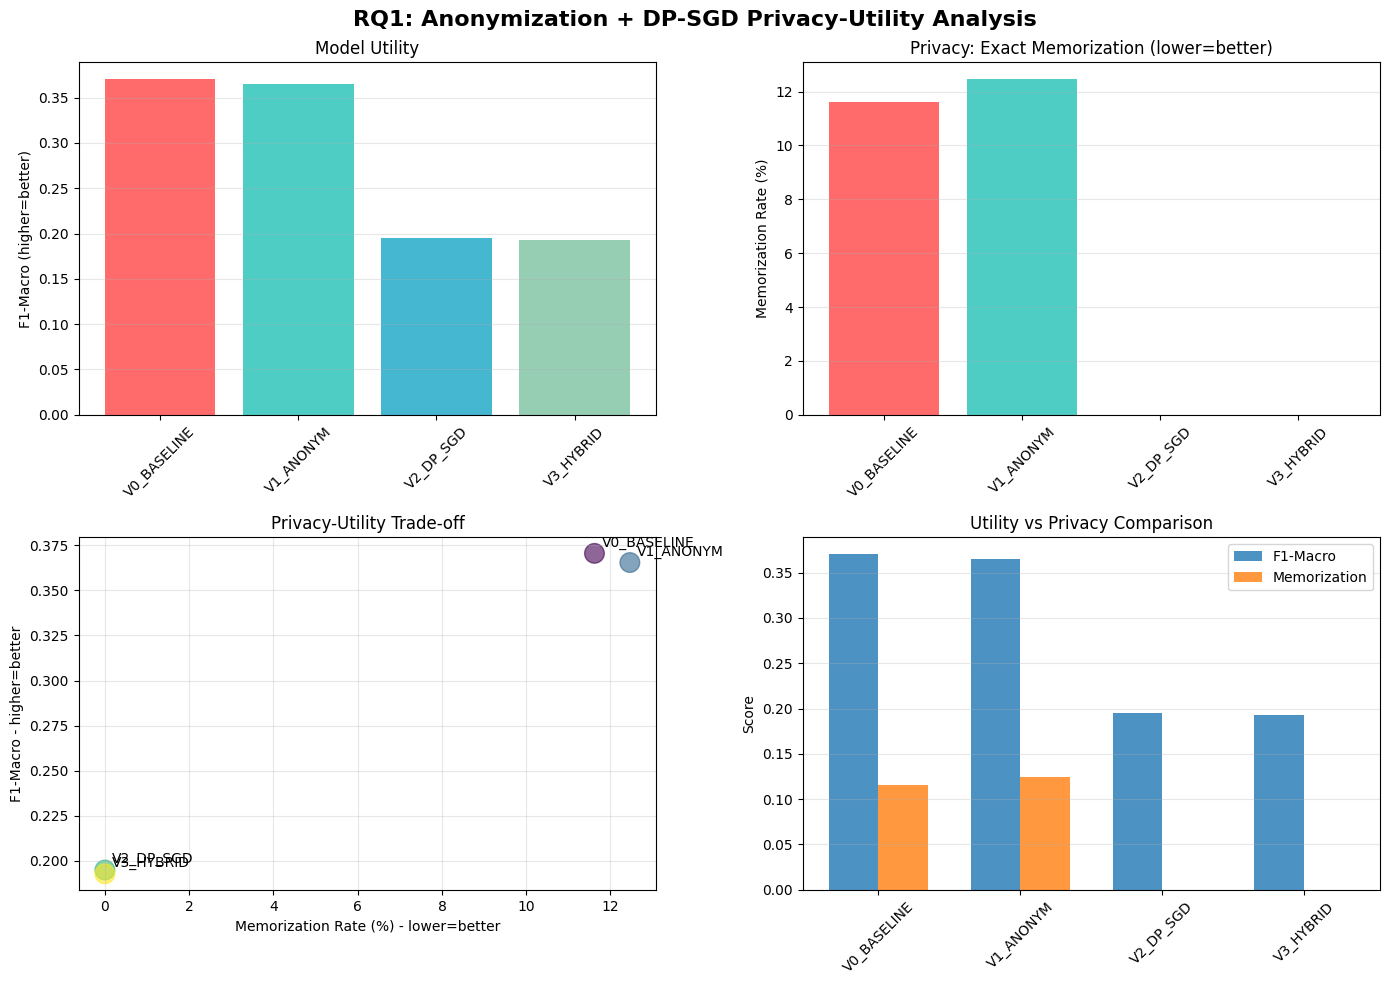

Visualization saved


In [24]:
# Combine results
final_results = eval_df.merge(privacy_df, on='variant')

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('RQ1: Anonymization + DP-SGD Privacy-Utility Analysis', fontsize=16, fontweight='bold')

# F1-Macro comparison
axes[0, 0].bar(final_results['variant'], final_results['f1_macro'], color=['#ff6b6b', '#4ecdc4', '#45b7d1', '#96ceb4'])
axes[0, 0].set_ylabel('F1-Macro (higher=better)')
axes[0, 0].set_title('Model Utility')
axes[0, 0].tick_params(axis='x', rotation=45)
axes[0, 0].grid(axis='y', alpha=0.3)

# Memorization rate (lower=better privacy)
axes[0, 1].bar(final_results['variant'], final_results['memorization_rate']*100, color=['#ff6b6b', '#4ecdc4', '#45b7d1', '#96ceb4'])
axes[0, 1].set_ylabel('Memorization Rate (%)')
axes[0, 1].set_title('Privacy: Exact Memorization (lower=better)')
axes[0, 1].tick_params(axis='x', rotation=45)
axes[0, 1].grid(axis='y', alpha=0.3)

# Privacy-Utility Trade-off
axes[1, 0].scatter(final_results['memorization_rate']*100, final_results['f1_macro'], s=200, alpha=0.6, c=range(len(final_results)))
for idx, row in final_results.iterrows():
    axes[1, 0].annotate(row['variant'], (row['memorization_rate']*100, row['f1_macro']), xytext=(5, 5), textcoords='offset points')
axes[1, 0].set_xlabel('Memorization Rate (%) - lower=better')
axes[1, 0].set_ylabel('F1-Macro - higher=better')
axes[1, 0].set_title('Privacy-Utility Trade-off')
axes[1, 0].grid(alpha=0.3)

# All metrics comparison
metrics_to_plot = ['f1_macro', 'memorization_rate']
x = np.arange(len(final_results))
width = 0.35
axes[1, 1].bar(x - width/2, final_results['f1_macro'], width, label='F1-Macro', alpha=0.8)
axes[1, 1].bar(x + width/2, final_results['memorization_rate'], width, label='Memorization', alpha=0.8)
axes[1, 1].set_xticks(x)
axes[1, 1].set_xticklabels(final_results['variant'], rotation=45)
axes[1, 1].set_ylabel('Score')
axes[1, 1].set_title('Utility vs Privacy Comparison')
axes[1, 1].legend()
axes[1, 1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(REPORT_DIR, 'rq1_analysis.png'), dpi=300, bbox_inches='tight')
plt.show()

print("Visualization saved")